<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Hierarchical Clustering Intuition</b>
</h1>
<div style="font-family:'Times New Roman';">
K-Means and DBSCAN were both flat clustering, you just get some clusters at the end and thats it. Hierarchical clustering is a bit diffrent, it builds a whole tree of clusters, going from every point being its own cluster all the way up to one big cluster. Then we get to cut the tree wherever we want.
<br><br>
Stuff i want to get clear here:
<ul>
<li>the two types, agglomerative and divisive</li>
<li>how it decides which clusters to merge (linkage)</li>
<li>what a dendrogram even is</li>
</ul>
</div>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Two ways to build the tree

There are two directions you can go:

- **Agglomerative (bottom up)** : every point starts as its own little cluster, then we keep merging the two closest clusters together, step by step, until everything is one big cluster. This is the one everyone actually uses.
- **Divisive (top down)** : the opposite, start with all the points in one cluster and keep splitting it into smaller ones. Its way more expensive so its rarely used in practice.

i'll focus on agglomerative since thats the common one and its what sklearn gives you.

## A tiny example by hand

Lets take just 5 points so we can actually follow the merging with our eyes. I'll keep them in 1d (just sitting on a line) so the distances are easy to see.

In [2]:
points = np.array([1, 2, 5, 8, 9], dtype=float)

# distance between every pair of points
n = len(points)
dist = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        dist[i, j] = abs(points[i] - points[j])

print(dist)

[[0. 1. 4. 7. 8.]
 [1. 0. 3. 6. 7.]
 [4. 3. 0. 3. 4.]
 [7. 6. 3. 0. 1.]
 [8. 7. 4. 1. 0.]]


The two closest points are 8 and 9 (distance 1), and also 1 and 2 (distance 1). Say we merge 8 and 9 first into one cluster, then 1 and 2. Now we have the clusters {1,2}, {5}, {8,9}. Next the closest clusters merge again, and this keeps going until everything is one cluster.

The order of these merges, and the distance at each merge, is exactly what a dendrogram draws later.

## How do we measure distance between two clusters?

When a cluster has more than one point in it, what is the distance between two clusters? This is where **linkage** comes in, and there are a few common choices:

- **Single linkage** : distance between the two closest points of the two clusters. Tends to make long stringy clusters.
- **Complete linkage** : distance between the two farthest points. Makes tight compact clusters.
- **Average linkage** : the average distance between all pairs of points across the two clusters.
- **Ward** : merges the two clusters that increase the total variance the least. Usually gives nice balanced clusters.

ward is a good default for normal blob like data, so i'll mostly use that one.

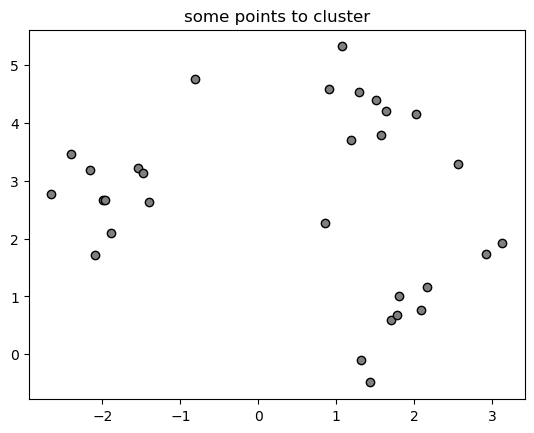

In [4]:
# just some points to picture what we are clustering
from sklearn.datasets import make_blobs
Xb, _ = make_blobs(n_samples=30, centers=3, cluster_std=0.7, random_state=0)

plt.scatter(Xb[:, 0], Xb[:, 1], color='gray', edgecolors='k')
plt.title('some points to cluster')
plt.show()

## What you actually get at the end

The nice thing is, unlike K-Means, you dont have to pick the number of clusters before running anything. You build the full tree first and then look at the dendrogram and decide where to cut it. Cut higher up and you get fewer clusters, cut lower and you get more.

The downside is its slow on big datasets, because it has to look at all the pairwise distances, so its not great for huge amounts of data.

So in my own words, hierarchical clustering keeps merging the closest clusters and records the whole history as a tree. Linkage is just the rule for what "closest" means.

Next notebook i'll actually run it with sklearn on the mall customers data, and after that draw the dendrogram and learn to read it properly.